In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow import keras
from copy import copy, deepcopy
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical

In [ ]:
# Replace __FILL_ME__ with your information

# Data preparation and prepcrossing

In [3]:
# load data
(data_train, label_train), (data_test, label_test) = mnist.load_data()

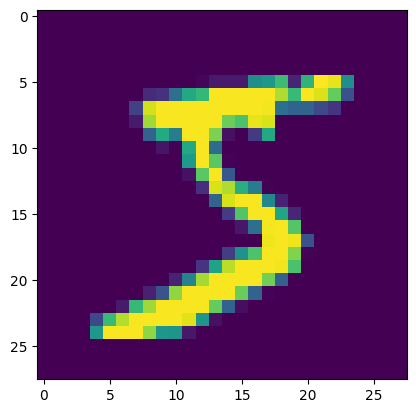

In [4]:
# display one test figure
test_fig = data_train[0]
plt.imshow(test_fig)

In [5]:
# normalize the data into the range of 0-1
data_train = data_train/data_train.max()
data_test = data_test/data_test.max()

Label = 0


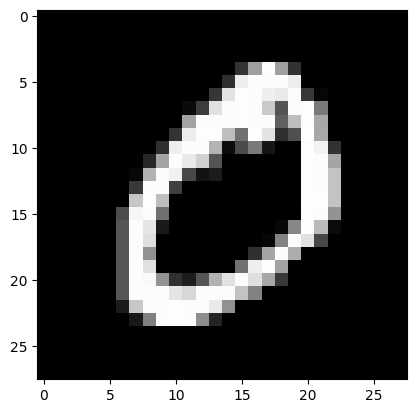

Label = 1


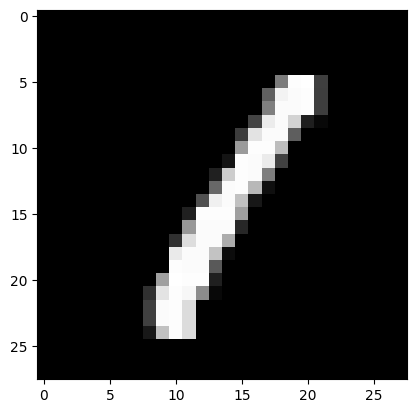

Label = 2


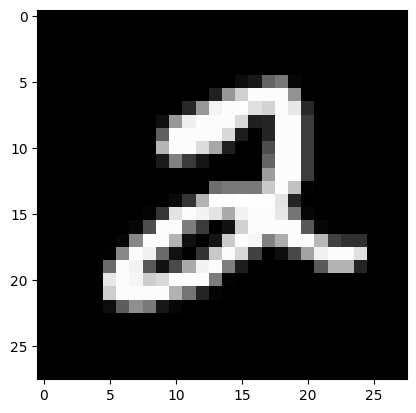

Label = 3


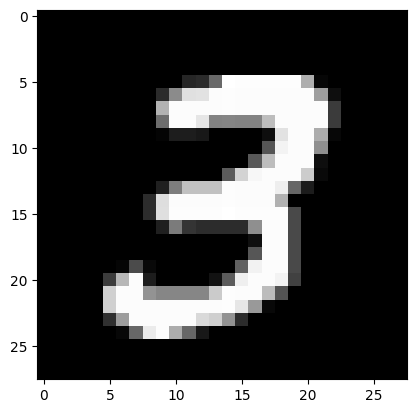

Label = 4


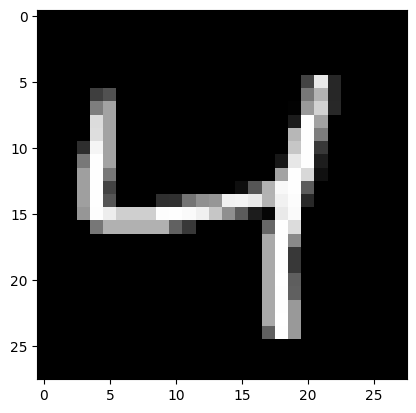

Label = 5


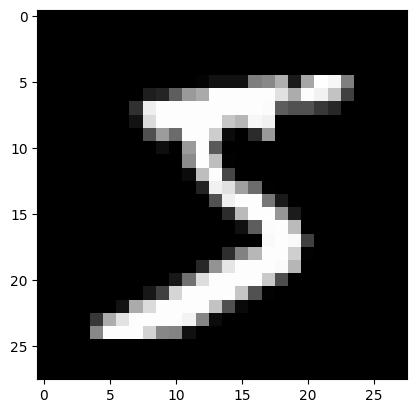

Label = 6


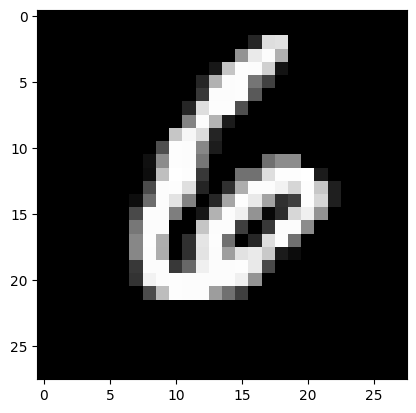

Label = 7


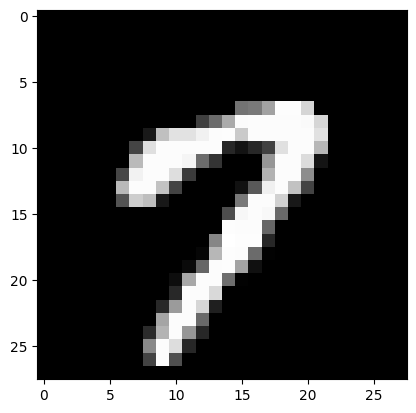

Label = 8


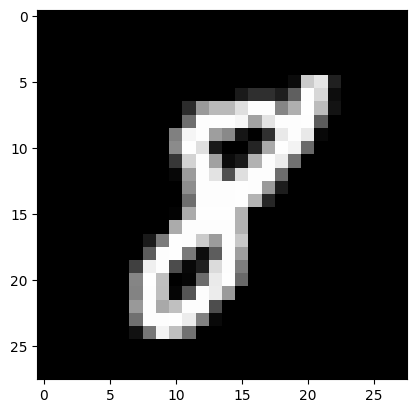

Label = 9


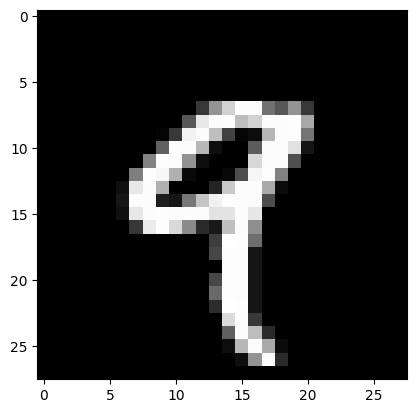

In [22]:
# display fig for each class
for i in range(10):
    for img_idx in range(10000):
        if int(label_train[img_idx]) == i:
            print('Label =', i)
            plt.imshow(data_train[img_idx],cmap = 'gray')
            plt.show()
            break
    

In [23]:
# 32 Floating Point data type is used

# 1. An MNIST image has a size of 28x28 pixels = 784 pixels
# 2. A float32 data type requires 32 bits = 4 bytes per pixel
# 3. Total memory in bytes = 28 * 28 * 4 bytes = 3136 bytes
# 4. Convert to KB by dividing by 1024 (standard binary definition)
mem_fig = (28 * 28 * 4) / 1024

print('The required memory useage for each figure is:{} kb' .format(mem_fig) )

The required memory useage for each figure is:3.0625 kb


# Construct the MLP

In [ ]:
# Considerations: number of layers, number of neurons in each layer, activation function

In [24]:
# Build up the MLP
# later you can change the number of neurons and layers

# Input layer matching the shape of a single MNIST image (28x28)
input_layer = Input(shape=data_train[0].shape)

# Flatten the 2D image (28x28) into a 1D vector (784 elements)
input_layer_f = Flatten()(input_layer)

# Hidden Layer 1: Dense layer with 5 neurons followed by ReLU activation
hidden_layer_1     = Dense(5, name='dense_1')(input_layer_f)
hidden_layer_1_act = Activation("relu", name="act_1")(hidden_layer_1)

# Hidden Layer 2: Dense layer with 8 neurons followed by ReLU activation
hidden_layer_2     = Dense(8, name='dense_2')(hidden_layer_1_act)
hidden_layer_2_act = Activation("relu", name="act_2")(hidden_layer_2)

# Hidden Layer 3: Dense layer with 8 neurons followed by ReLU activation
hidden_layer_3     = Dense(8, name='dense_3')(hidden_layer_2_act)
hidden_layer_3_act = Activation("relu", name="act_3")(hidden_layer_3)

# Output Layer: 10 neurons corresponding to the 10 digit classes (0-9)
output_layer       = Dense(10, name='output_layer')(hidden_layer_3_act)

# Softmax activation to output probability distributions for classification
output_layer_act   = Activation("softmax", name="softmax")(output_layer)

# Instantiate the Keras Model
model = Model(input_layer, output_layer_act)

In [25]:
parameter_by_layer = np.zeros([4])

# layer 1: (784 inputs * 5 outputs) + 5 biases
parameter_by_layer[0] = (784 * 5) + 5

# layer 2: (5 inputs * 8 outputs) + 8 biases
parameter_by_layer[1] = (5 * 8) + 8

# layer 3: (8 inputs * 8 outputs) + 8 biases
parameter_by_layer[2] = (8 * 8) + 8

# layer 4: (8 inputs * 10 outputs) + 10 biases
parameter_by_layer[3] = (8 * 10) + 10

# Summing all layer parameters
mem_weights = parameter_by_layer.sum()

# Convert parameters to memory (4 bytes per float32) and convert to KB (divide by 1024)
mem_kb = (mem_weights * 4) / 1024
            
print('The total memory useage for weight and bias is {} kb'.format(mem_kb))

The total memory useage for weight and bias is 16.15234375 kb


In [26]:
# check the parameter numbers
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           3,925 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ act_1 (Activation)                   │ (None, 5)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ act_2 (Activation)                   │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ act_3 (Activation)                   │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 10)                  │              90 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax (Activation)                 │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,135 (16.15 KB)

 Trainable params: 4,135 (16.15 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [27]:
# compile model
# define optimizer to perform backpropagation, loss function to evaluate loss
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [28]:
# train model with 80% data for training and 20% for validation with specified number of epochs, a small number is reconmmand (10)
r= model.fit(data_train, label_train,  validation_split= 0.2, epochs=10)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.6788 - loss: 0.9501 - val_accuracy: 0.8564 - val_loss: 0.4841
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8634 - loss: 0.4674 - val_accuracy: 0.8727 - val_loss: 0.4159
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8769 - loss: 0.4220 - val_accuracy: 0.8838 - val_loss: 0.3886
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8817 - loss: 0.4006 - val_accuracy: 0.8896 - val_loss: 0.3761
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8874 - loss: 0.3848 - val_accuracy: 0.8919 - val_loss: 0.3650
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8893 - loss: 0.3758 - val_accuracy: 0.8907 - val_loss: 0.3636
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8919 - loss: 0.3653 - val_accuracy: 0.8946 - val_loss: 0.3516
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8945 - loss: 0.3581 -

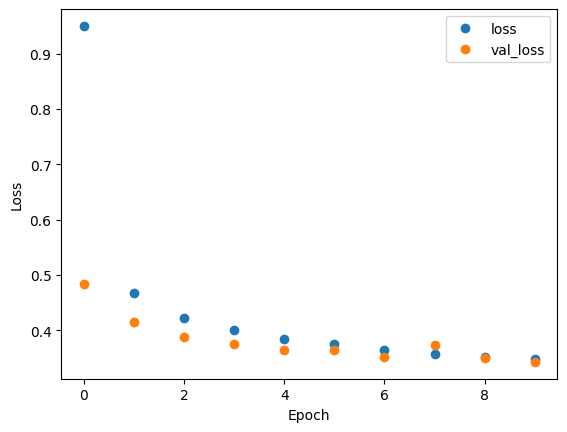

In [29]:
# plot loss
plt.plot(r.history['loss'],  'o', label='loss')
plt.plot(r.history['val_loss'],'o', label='val_loss',)
plt.ylabel('Loss')  # Set the label for the y-axis
plt.xlabel('Epoch')  # Set the label for the x-axis
plt.legend()
plt.show()

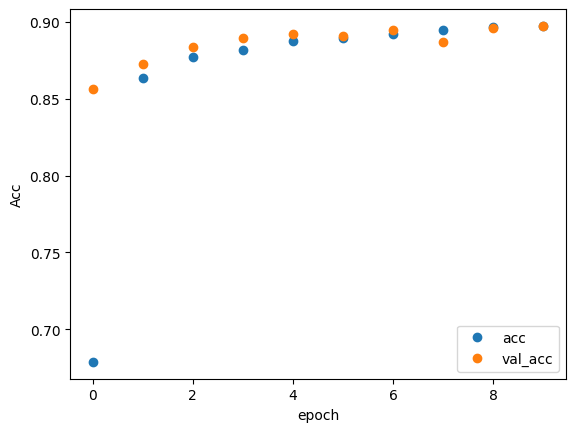

In [30]:
# Plot accuracy
plt.plot(r.history['accuracy'], 'o', label='acc')
plt.plot(r.history['val_accuracy'], 'o', label='val_acc')
plt.xlabel('epoch')
plt.ylabel('Acc')
plt.legend()
plt.show()

In [31]:
# Evaluate the model with test dataset - evaluate() returns loss and accuracy
print("Train Acc", model.evaluate(data_train, label_train)[1])
acc_floatingpoint =  model.evaluate(data_test, label_test)[1]
print("Test Acc:",acc_floatingpoint )

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8994 - loss: 0.3377
Train Acc 0.8993833065032959
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8944 - loss: 0.3587
Test Acc: 0.8944000005722046


In [32]:
# save model weights
model.save_weights("weights_floatingpoint.weights.h5")

Text(0, 0.5, 'Number')

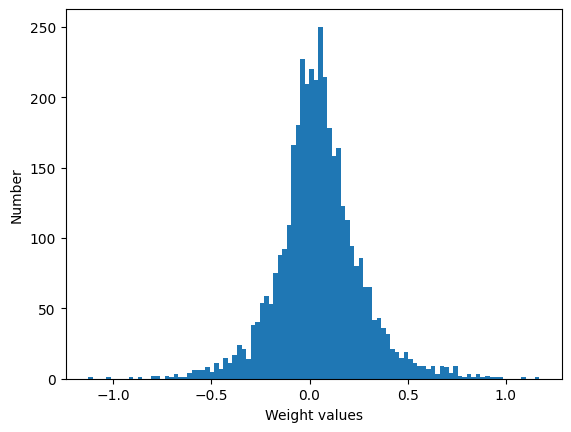

In [33]:
# observe the statistics of weights, for example in the first layer
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Number')

In [ ]:
# # What can you observe from the distribution of weights?
# Gaussian (Normal) Distribution: The weights follow a symmetric, bell-shaped distribution centered almost exactly at $0.0$.Narrow Dynamic Range: The vast majority of weight values are tightly clustered between $-0.5$ and $+0.5$, with very few extreme outliers extending past $\pm 1.0$.Suitability for Quantization: Because the values are concentrated in such a small range, we do not need a large integer bit-width ($BW\_int = 2$ is more than enough to prevent overflow). This allows us to dedicate more bits to the fractional part ($BW\_frac$) to maintain high model precision.

# Implement of the trained MLP with numpy

In [34]:
# implement the dense layer
def dense_layer (input_mat, input_vec, bias):
    # Perform matrix multiplication: output = input_vector * weights + bias
    output = np.dot(input_vec, input_mat) + bias
    return output

In [35]:
# implement the ReLU activation function
def ReLU_layer (in_activations):
    out_activations = np.zeros(in_activations.shape)
    for i in range(len(in_activations)):
        # If the input activation is greater than zero, keep it
        if in_activations[i] > 0:
            out_activations[i] = in_activations[i]
    return out_activations

In [37]:
# implement the softmax activation function
def softmax_layer (in_activations):
    out_activations = np.zeros(in_activations.shape)
    # Subtracting the max value prevents numerical overflow (NaN errors)
    shift_activations = in_activations - np.max(in_activations)
    exp_sum = np.sum(np.exp(shift_activations))
    for i in range(len(in_activations)):
       out_activations[i] = np.exp(shift_activations[i]) / exp_sum
    return out_activations

In [24]:
# implement your own MLP, the weighs & biases should be extracted by model.get_weights()
# the softmax layer is not necessary to be implemented

# Dynamically filter only the layers that contain weights (Dense layers)
dense_layers = [layer for layer in model.layers if len(layer.get_weights()) > 0]
W1, b1 = dense_layers[0].get_weights()
W2, b2 = dense_layers[1].get_weights()
W3, b3 = dense_layers[2].get_weights()
W4, b4 = dense_layers[3].get_weights()

input_example_np = np.ones([28*28])

# Pass forward sequentially through the MLP layers
output_1 = ReLU_layer(dense_layer(W1, input_example_np, b1))
output_2 = ReLU_layer(dense_layer(W2, output_1, b2))
output_3 = ReLU_layer(dense_layer(W3, output_2, b3))
output_4 = softmax_layer(dense_layer(W4
                                     , output_3, b4))

NameError: name 'output_4' is not defined

In [39]:
# Compare with the reference
model.predict(tf.ones((1, 28, 28)), steps=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


array([[2.6479383e-31, 6.1522349e-36, 1.2311979e-25, 1.0000000e+00,
        0.0000000e+00, 1.3998421e-18, 0.0000000e+00, 4.6522363e-26,
        5.2493434e-17, 3.0518866e-32]], dtype=float32)

# MLP fixed point quantization

In [27]:
# Quantized the weights and evaluate the best combination of Integer and Fractional parts
# Compare the inference acc. with TF model
# Estimate how much memory storage you can save with quantization 

In [40]:
# function to quantize weights with speficied bit width for integer and fractional part
def fixP_quantization(input_weight, int_BW, frac_BW):
    # LSB step size: smallest value representable by the fractional bits
    resolution_ = 2 ** (-frac_BW)
    
    # Negative boundary limit (magnitude) determined by the integer bits
    range_ = 2 ** int_BW 
    
    # Create a deep copy to avoid modifying the original weight array in-place
    weight = deepcopy(input_weight)
    
    # Clip weights to the safe signed fixed-point range: [-range, range - resolution]
    input_weight_clipped = np.clip(weight, -range_, range_ - resolution_) 
    
    # Scale to integer grid, round to the nearest whole number, and scale back
    input_weight_quantized = np.round(input_weight_clipped / resolution_) * resolution_
    
    return input_weight_quantized

In [41]:
# weight_quantization
BW_int = 2      # 2 bits for integer part (covers safe range up to [-4.0, 3.0])
BW_frac = 5     # 5 bits for fractional part (provides high precision step of 0.03125)

In [42]:
weight_quantized = [deepcopy(w) for w in model.get_weights()]

In [43]:
for i in range(len(weight_quantized)):
    weight_quantized[i] = fixP_quantization(np.copy(weight_quantized[i]), BW_int, BW_frac)

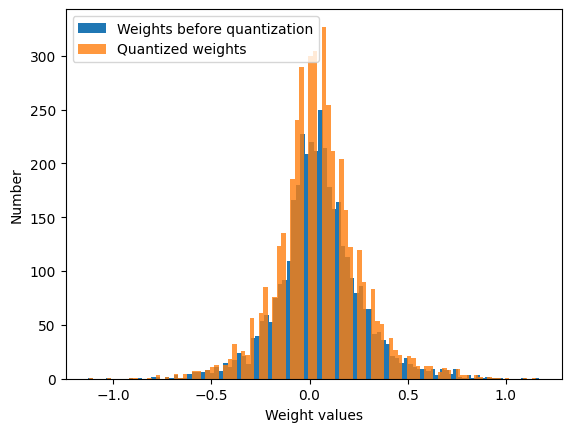

In [44]:
# plot the quantized weights in the first layer as example and compare with the floating point
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100, label = 'Weights before quantization', alpha = 1)
_ = plt.hist((weight_quantized[0].flatten()), bins = 100, label = 'Quantized weights', alpha = 0.8)
plt.xlabel('Weight values')
plt.ylabel('Number')

plt.legend()

In [45]:
# define the quantized model
model_quantized = Model(input_layer, output_layer_act)

In [46]:
# Load weights and save
model_quantized.set_weights(weight_quantized)
model_quantized.save_weights("weights_q_int{}_frac_{}.weights.h5".format(BW_int, BW_frac))

# Evaluation of the quantization 

In [47]:
model_quantized.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [48]:
# Evaluate the model - evaluate() returns loss and accuracy
print("Train Acc", model_quantized.evaluate(data_train, label_train)[1])
acc_quantized = model_quantized.evaluate(data_test, label_test)[1]
print("Test Acc:", acc_quantized)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8923 - loss: 0.3550
Train Acc 0.8923333287239075
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8882 - loss: 0.3781
Test Acc: 0.8881999850273132


In [49]:
# Summary
# 32 FP numbers utilized in baseline model

# Calculate the fraction of memory saved: (32 bits - 8 bits) / 32 bits
saved_memory = (32 - (1 + BW_int + BW_frac)) / 32

# Compute the accuracy difference between the original floating-point and quantized model
acc_drop = acc_floatingpoint - acc_quantized

In [50]:
print("Saved memory: {}% ".format(saved_memory*100))
print("Accuracy drop: {:.2f}%" .format(acc_drop*100))

Saved memory: 75.0% 
Accuracy drop: 0.62%


# Systematic evaluation

In [51]:
# parameter sweep, Look for the optimal combination
BW_int = 1
acc_quantized_BW_int_1 = np.zeros(31)
saved_memory_BW_int_1 = np.zeros(31)

# Loop 31 times (from frac_BW = 0 to 30)
for i in range(31):
    BW_frac = i
    
    weight_quantized = [np.copy(w) for w in model.get_weights()]
    
    # quantize weights layer by layer
    for j in range(len(weight_quantized)):
        weight_quantized[j] = fixP_quantization(weight_quantized[j], BW_int, BW_frac)
    
    # define the quantized model
    model_quantized = Model(input_layer, output_layer_act)
    
    # load quantized weights
    model_quantized.set_weights(weight_quantized)
    
    # save quantized weights with valid Keras 3 extension
    model_quantized.save_weights("weights_q_int{}_frac_{}.weights.h5".format(BW_int, BW_frac))
    
    # compile model
    model_quantized.compile(optimizer='adam',
                            loss='sparse_categorical_crossentropy',
                            metrics=['accuracy'])
    
    print("BW_int = {} BW_frac = {} ".format(BW_int, BW_frac))
    
    # acc evaluation (index 1 contains the accuracy)
    acc_quantized_BW_int_1[i] = model_quantized.evaluate(data_test, label_test, verbose=0)[1]
    
    # save memory evaluation (ratio of memory saved)
    saved_memory_BW_int_1[i] = (32 - (1 + BW_int + BW_frac)) / 32
    print("The saved memory is {}".format(saved_memory_BW_int_1[i]))

BW_int = 1 BW_frac = 0 
The saved memory is 0.9375
BW_int = 1 BW_frac = 1 
The saved memory is 0.90625
BW_int = 1 BW_frac = 2 
The saved memory is 0.875
BW_int = 1 BW_frac = 3 
The saved memory is 0.84375
BW_int = 1 BW_frac = 4 
The saved memory is 0.8125
BW_int = 1 BW_frac = 5 
The saved memory is 0.78125
BW_int = 1 BW_frac = 6 
The saved memory is 0.75
BW_int = 1 BW_frac = 7 
The saved memory is 0.71875
BW_int = 1 BW_frac = 8 
The saved memory is 0.6875
BW_int = 1 BW_frac = 9 
The saved memory is 0.65625
BW_int = 1 BW_frac = 10 
The saved memory is 0.625
BW_int = 1 BW_frac = 11 
The saved memory is 0.59375
BW_int = 1 BW_frac = 12 
The saved memory is 0.5625
BW_int = 1 BW_frac = 13 
The saved memory is 0.53125
BW_int = 1 BW_frac = 14 
The saved memory is 0.5
BW_int = 1 BW_frac = 15 
The saved memory is 0.46875
BW_int = 1 BW_frac = 16 
The saved memory is 0.4375
BW_int = 1 BW_frac = 17 
The saved memory is 0.40625
BW_int = 1 BW_frac = 18 
The saved memory is 0.375
BW_int = 1 BW_frac = 

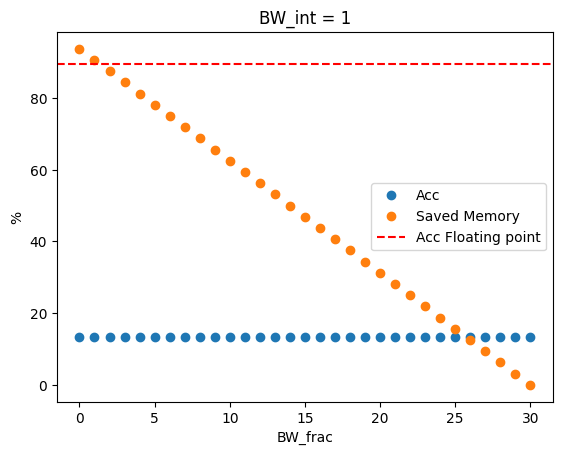

In [53]:
# result visualization
plt.plot(acc_quantized_BW_int_1*100, 'o', label = 'Acc')
plt.plot(saved_memory_BW_int_1*100, 'o', label = 'Saved Memory')
plt.xlabel('BW_frac')
plt.ylabel('%')
plt.axhline(y = acc_floatingpoint*100, color = 'r', linestyle = '--', label = "Acc Floating point")
plt.legend()
plt.title("BW_int = 1")
plt.show()

In [55]:
# parameter sweep
BW_int = 2
acc_quantized_BW_int_2 = np.zeros(30)
saved_memory_BW_int_2 = np.zeros(30)

# Loop 30 times (from frac_BW = 0 to 29)
for i in range(30):
    BW_frac = i
    
    weight_quantized = [np.copy(w) for w in model.get_weights()]
    
    # quantize weights layer by layer
    for j in range(len(weight_quantized)):
        weight_quantized[j] = fixP_quantization(weight_quantized[j], BW_int, BW_frac)
        
    # define the quantized model
    model_quantized = Model(input_layer, output_layer_act)
    
    # load quantized weights
    model_quantized.set_weights(weight_quantized)
    
    # save quantized weights with valid Keras 3 extension
    model_quantized.save_weights("weights_q_int{}_frac_{}.weights.h5".format(BW_int, BW_frac))
    
    # compile model
    model_quantized.compile(optimizer='adam',
                            loss='sparse_categorical_crossentropy',
                            metrics=['accuracy'])
    
    print("BW_int = {} BW_frac = {} ".format(BW_int, BW_frac))
    
    # acc evaluation (index 1 contains the accuracy)
    acc_quantized_BW_int_2[i] = model_quantized.evaluate(data_test, label_test, verbose=0)[1]
    
    # save memory evaluation (ratio of memory saved)
    saved_memory_BW_int_2[i] = (32 - (1 + BW_int + BW_frac)) / 32
    print("The saved memory is {}".format(saved_memory_BW_int_2[i]))

BW_int = 2 BW_frac = 0 
The saved memory is 0.90625
BW_int = 2 BW_frac = 1 
The saved memory is 0.875
BW_int = 2 BW_frac = 2 
The saved memory is 0.84375
BW_int = 2 BW_frac = 3 
The saved memory is 0.8125
BW_int = 2 BW_frac = 4 
The saved memory is 0.78125
BW_int = 2 BW_frac = 5 
The saved memory is 0.75
BW_int = 2 BW_frac = 6 
The saved memory is 0.71875
BW_int = 2 BW_frac = 7 
The saved memory is 0.6875
BW_int = 2 BW_frac = 8 
The saved memory is 0.65625
BW_int = 2 BW_frac = 9 
The saved memory is 0.625
BW_int = 2 BW_frac = 10 
The saved memory is 0.59375
BW_int = 2 BW_frac = 11 
The saved memory is 0.5625
BW_int = 2 BW_frac = 12 
The saved memory is 0.53125
BW_int = 2 BW_frac = 13 
The saved memory is 0.5
BW_int = 2 BW_frac = 14 
The saved memory is 0.46875
BW_int = 2 BW_frac = 15 
The saved memory is 0.4375
BW_int = 2 BW_frac = 16 
The saved memory is 0.40625
BW_int = 2 BW_frac = 17 
The saved memory is 0.375
BW_int = 2 BW_frac = 18 
The saved memory is 0.34375
BW_int = 2 BW_frac =

Text(0.5, 1.0, 'BW_int = 2')

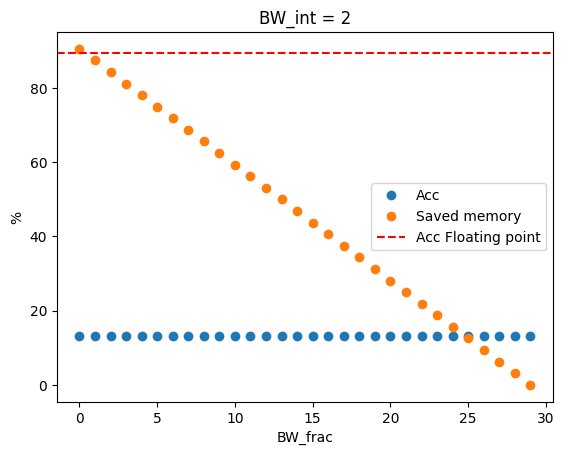

In [56]:
plt.plot(acc_quantized_BW_int_2*100, 'o', label = 'Acc')
plt.plot(saved_memory_BW_int_2*100, 'o', label = 'Saved memory')
plt.axhline(y = acc_floatingpoint*100, color = 'r', linestyle = '--', label = "Acc Floating point")
plt.xlabel('BW_frac')
plt.ylabel('%')
plt.legend()
plt.title("BW_int = 2")

# Pruning

In [76]:
# load lib
# if something goes wrong
# run pip install tensorflow==2.4.1
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning, prune_low_magnitude

In [78]:
# parameters for training the pruned model
batch_size = 32
epochs = 10
num_images = 60000
 
end_step = np.ceil(num_images / batch_size).astype(np.int32) * epochs

In [79]:
# Thêm dòng import này ở đầu ô code:
from tensorflow_model_optimization.python.core.keras.compat import keras as compat_keras

input_layer_compat = compat_keras.Input(shape=data_train[0].shape)
input_layer_f = compat_keras.layers.Flatten()(input_layer_compat)

hidden_layer_1     = compat_keras.layers.Dense(5, name='dense_1_compat')(input_layer_f)
hidden_layer_1_act = compat_keras.layers.Activation("relu", name="act_1_compat")(hidden_layer_1)

hidden_layer_2     = compat_keras.layers.Dense(8, name='dense_2_compat')(hidden_layer_1_act)
hidden_layer_2_act = compat_keras.layers.Activation("relu", name="act_2_compat")(hidden_layer_2)

hidden_layer_3     = compat_keras.layers.Dense(8, name='dense_3_compat')(hidden_layer_2_act)
hidden_layer_3_act = compat_keras.layers.Activation("relu", name="act_3_compat")(hidden_layer_3)

output_layer       = compat_keras.layers.Dense(10, name='output_layer_compat')(hidden_layer_3_act)
output_layer_act   = compat_keras.layers.Activation("softmax", name="softmax_compat")(output_layer)

model_legacy = compat_keras.Model(input_layer_compat, output_layer_act)

# Sao chép trọng số từ model gốc đã train của bạn sang
model_legacy.set_weights(model.get_weights())

In [80]:
# Define model for pruning.
pruning_params = {
      'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.00,
                                                               final_sparsity=0.80,
                                                               begin_step=3000,
                                                               end_step=end_step)
}

In [70]:
pruned_model = prune_low_magnitude(model_legacy, **pruning_params)

In [71]:
# `prune_low_magnitude` requires a recompile.
pruned_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

pruned_model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 prune_low_magnitude_flatte  (None, 784)               1         
 n (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 5)                 7847      
 1_compat (PruneLowMagnitud                                      
 e)                                                              
                                                                 
 prune_low_magnitude_act_1_  (None, 5)                 1         
 compat (PruneLowMagnitude)                                      
                                                                 
 prune_low_magnitude_dense_  (None, 8)                 90   

In [72]:
#Keras callback which updates pruning wrappers with the optimizer step. 
#This callback must be used when training a model which needs to be pruned. Not doing so will throw an error.

callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),]


history = pruned_model.fit(data_train,
                           label_train,
                           batch_size=batch_size,
                           epochs=epochs, 
                           validation_split = 0.20,
                           callbacks=callbacks)

Epoch 1/10


1500/1500 [==============================] - 19s 6ms/step - loss: 0.9025 - accuracy: 0.7164 - val_loss: 0.5075 - val_accuracy: 0.8484
Epoch 2/10
1500/1500 [==============================] - 8s 5ms/step - loss: 0.4851 - accuracy: 0.8602 - val_loss: 0.4252 - val_accuracy: 0.8726
Epoch 3/10
1500/1500 [==============================] - 8s 5ms/step - loss: 0.4294 - accuracy: 0.8761 - val_loss: 0.4025 - val_accuracy: 0.8773
Epoch 4/10
1500/1500 [==============================] - 8s 5ms/step - loss: 0.4028 - accuracy: 0.8817 - val_loss: 0.3728 - val_accuracy: 0.8884
Epoch 5/10
1500/1500 [==============================] - 8s 5ms/step - loss: 0.4097 - accuracy: 0.8818 - val_loss: 0.4048 - val_accuracy: 0.8803
Epoch 6/10
1500/1500 [==============================] - 8s 5ms/step - loss: 0.5363 - accuracy: 0.8390 - val_loss: 0.7594 - val_accuracy: 0.7570
Epoch 7/10
1500/1500 [==============================] - 8s 5ms/step - loss: 0.5695 - accuracy: 0.8257 - val_loss: 0.5406 - val_accura

In [73]:
acc_pruned_model = pruned_model.evaluate(data_test, label_test)[1]

313/313 [==============================] - 2s 3ms/step - loss: 1.0836 - accuracy: 0.6500


In [74]:
pruned_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 prune_low_magnitude_flatte  (None, 784)               1         
 n (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 5)                 7847      
 1_compat (PruneLowMagnitud                                      
 e)                                                              
                                                                 
 prune_low_magnitude_act_1_  (None, 5)                 1         
 compat (PruneLowMagnitude)                                      
                                                                 
 prune_low_magnitude_dense_  (None, 8)                 90    

Text(0, 0.5, 'Amount')

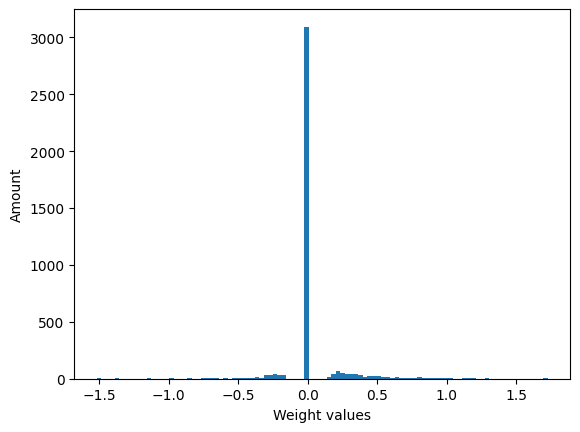

In [81]:
# display the weights in 1st layer of the pruned model
_ = plt.hist((pruned_model.get_weights()[1]).flatten(), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Amount')

Text(0, 0.5, 'Amount')

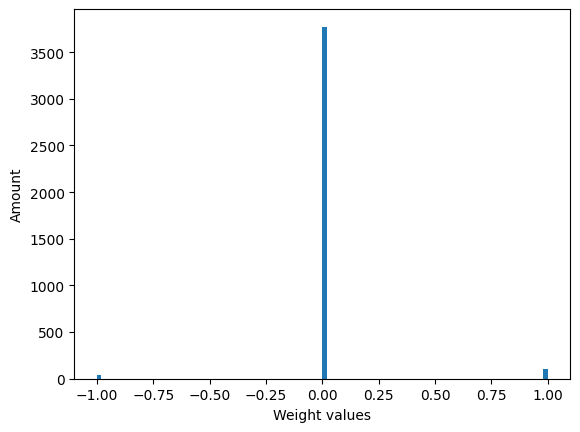

In [82]:
# compare with the original model
_ = plt.hist((model.get_weights()[0]).flatten(), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Amount')

In [ ]:
# calculate the saved memory
# simple assumption: "0" doesn't occupy the space


In [83]:
# compute the saved memory space 
weights_total = mem_weights
get_weights_idx = [3, 9, 15, 21]

# Make sure to initialize this variable to 0 before the loop
weights_pruned = 0 

for i in range(4):
    weights_pruned += pruned_model.get_weights()[get_weights_idx[i]].sum()

# Remaining weights in the pruned model
weights_pruned_remained = weights_pruned

In [84]:
acc_drop_prun =acc_floatingpoint - acc_pruned_model 

In [ ]:
print("The saved memory space by pruning is {:.3f}%" .format((1-weights_pruned_remained/weights_total)*100))
print("The accuracy drop is {:.3f}%" .format(acc_drop_prun*100))

# Systematic evaluation

In [ ]:
sparisty_vec = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
acc_prun_vec = np.zeros(len(sparisty_vec))

In [ ]:
for i in range(len(sparisty_vec)):
    # 1. Reset the legacy model to the original weights before applying new pruning
    model_legacy.set_weights(model.get_weights())
    
    # 2. Define model parameters for the current level of sparsity
    pruning_params = {
      'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.00,
                                                               final_sparsity=sparisty_vec[i],
                                                               begin_step=3000,
                                                               end_step=end_step)}
    
    # Apply low-magnitude pruning to the compatible legacy model
    pruned_model = prune_low_magnitude(model_legacy, **pruning_params)
    
    # Compile the pruned model
    pruned_model.compile(optimizer='adam',
                         loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                         metrics=['accuracy'])
    
    callbacks = [
        tfmot.sparsity.keras.UpdatePruningStep(),
    ]

    # Train the model to recover accuracy under the new sparsity constraint
    history = pruned_model.fit(data_train,
                               label_train,
                               batch_size=batch_size,
                               epochs=epochs, 
                               validation_split=0.20,
                               callbacks=callbacks,
                               verbose=0) # Set to 0 to keep the output clean during the sweep
    
    # Evaluate and store the accuracy on the test set
    acc_prun_vec[i] = pruned_model.evaluate(data_test, label_test, verbose=0)[1]
    print("Sparsity: {:.2f} - Test Accuracy: {:.4f}".format(sparisty_vec[i], acc_prun_vec[i]))

In [ ]:
plt.plot(sparisty_vec, acc_prun_vec*100, 'o', label = 'Pruned Model')
plt.axhline(y = acc_floatingpoint*100, color = 'r', linestyle = '--', label = "Acc Floating point")
plt.xlabel('Saved Memory')
plt.ylabel('%')
plt.legend()